In [23]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme()
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        os.path.join(dirname, filename)

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

## Import important libraries

In [2]:
import torch
from torch.utils.data import Dataset

import torchaudio
import torchaudio.transforms as T

import librosa
import librosa.display

from tqdm import tqdm
from typing import List
import scipy.stats as stats
from scipy.io.wavfile import write
from collections import defaultdict

In [ ]:
# Important variables
# I've trained all models on kaggle's notebook, if you have GPU then you can download dataset from ICBHI website replace all paths with you current directory's path.

ROOT_PATH = "/kaggle/input/datasets/vbookshelf/respiratory-sound-database/Respiratory_Sound_Database/Respiratory_Sound_Database/audio_and_txt_files"
OUT_PATH = "/kaggle/working/"
CSV_PATH = "/kaggle/input/datasets/vbookshelf/respiratory-sound-database/Respiratory_Sound_Database/Respiratory_Sound_Database/patient_diagnosis.csv"
PATIENT_INFO_PATH = "/kaggle/input/datasets/vbookshelf/respiratory-sound-database/demographic_info.txt"

SAMPLING_RATE = 16000
PAD_SIZE = 4.5 # In seconds
WINDOW_SIZE = int(PAD_SIZE * SAMPLING_RATE)

### Load patient diagonsis file to get disease class of each patient.

In [4]:
patient_disease_class_df = pd.read_csv(
    CSV_PATH,
    names=[
        'patient_number', 
        'disease_class'
    ]
)
patient_disease_class_df.head()

,patient_number,disease_class
0,101,URTI
1,102,Healthy
2,103,Asthma
3,104,COPD
4,105,URTI


In [5]:
patient_disease_class_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 126 entries, 0 to 125
Data columns (total 2 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   patient_number  126 non-null    int64 
 1   disease_class   126 non-null    object
dtypes: int64(1), object(1)
memory usage: 2.1+ KB


In [6]:
print(f"Total number of Unique patients: {patient_disease_class_df.shape[0]}")
print(f"Total number of Unique Disease: {len(patient_disease_class_df['disease_class'].value_counts())}")

Total number of Unique patients: 126
Total number of Unique Disease: 8


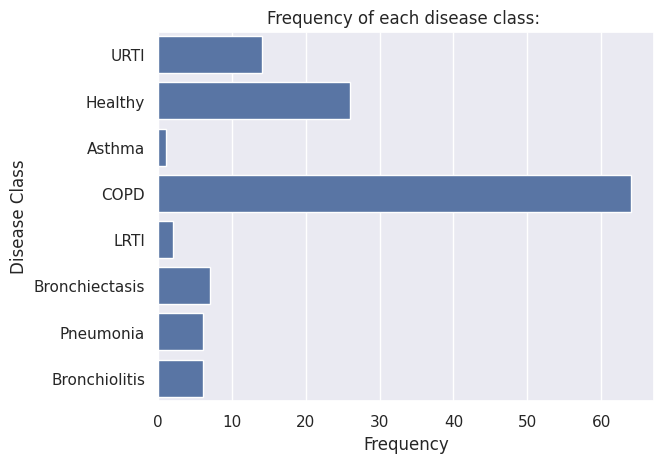

In [7]:
sns.countplot(patient_disease_class_df['disease_class'])
plt.xlabel("Frequency")
plt.ylabel("Disease Class")
plt.title("Frequency of each disease class: ")
plt.show()

In [8]:
# Cretae a dictionary which contains patient's number and their disease
patient_disease_class = {}

for patient_num, class_ in zip(
    patient_disease_class_df['patient_number'],
    patient_disease_class_df['disease_class']
):
    patient_disease_class[patient_num] = class_

In [9]:
p_info_df = pd.read_csv(
    PATIENT_INFO_PATH, 
    sep=' ', 
    header=None,
    names=['patient_id', 'age', 'sex', 'bmi', 'child_weight', 'child_height']
)
print(p_info_df.shape)
p_info_df.head()

(126, 6)


,patient_id,age,sex,bmi,child_weight,child_height
0,101,3.00,F,NaN,19.0,99.0
1,102,0.75,F,NaN,9.8,73.0
2,103,70.00,F,33.00,NaN,NaN
3,104,70.00,F,28.47,NaN,NaN
4,105,7.00,F,NaN,32.0,135.0


In [10]:
p_info_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 126 entries, 0 to 125
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   patient_id    126 non-null    int64  
 1   age           125 non-null    float64
 2   sex           125 non-null    object 
 3   bmi           75 non-null     float64
 4   child_weight  44 non-null     float64
 5   child_height  42 non-null     float64
dtypes: float64(4), int64(1), object(1)
memory usage: 6.0+ KB


In [11]:
p_info_df.describe()

,patient_id,age,bmi,child_weight,child_height
count,126.000000,125.00000,75.000000,44.000000,42.000000
mean,163.500000,42.99264,27.190000,21.361136,104.652381
std,36.517119,32.20907,5.372519,17.150885,30.793128
min,101.000000,0.25000,16.500000,7.140000,64.000000
25%,132.250000,4.00000,24.150000,11.755000,81.250000
50%,163.500000,60.00000,27.400000,15.100000,99.500000
75%,194.750000,71.00000,29.185000,24.325000,117.750000
max,226.000000,93.00000,53.500000,80.000000,183.000000


<Axes: xlabel='bmi', ylabel='Count'>

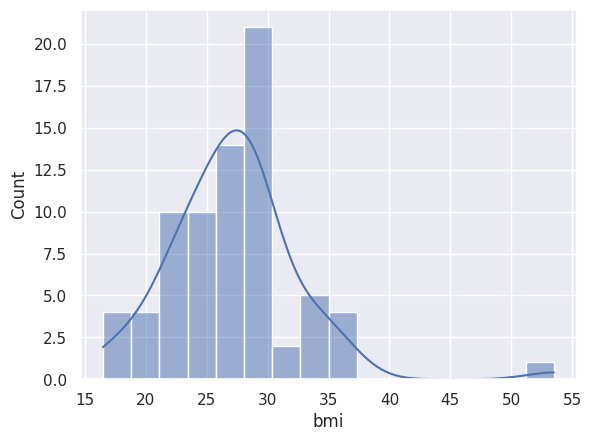

In [12]:
sns.histplot(p_info_df['bmi'], kde=True)

## Save each repiratory cycle.

In [13]:
def get_label(
    crackles: str = 0, 
    wheezes: str = 1
) -> int:
    """
    A function used to get class of crackles and wheezes combination.

    Args:
        crackles (str): Crackles sound (1=present, 0=non_present)
        wheezes (str): Wheeze sound (1=present, 0=non_present)
    Return:
        class_ (int): Class of combination.
    """
    if crackles == 0 and wheezes == 0:
        return 0  # normal
    elif crackles == 1 and wheezes == 0:
        return 1  # crackles
    elif crackles == 0 and wheezes == 1:
        return 2  # wheeze
    else:
        return 3  # both

CLS_TO_CYCLE_LABEL = {
    '0': "Normal",
    '1': "Crackles",
    '2': "Wheezes",
    '3': "Both",
}

In [14]:
def save_cycles(
    root_dir: str = None,
    out_dir: str = None
):
    all_files = os.listdir(root_dir)
    all_files.sort()
    
    for files in tqdm(all_files, desc="Saving cycles..."):
        PATIENT_ID = files.split('_')[0]
        
        wave_file = os.path.join(root_dir, files.replace('txt', 'wav'))

        waveform, sampling_rate = librosa.load(wave_file)

        text_file = files.replace('wav', 'txt')
        text_file_path = os.path.join(root_dir, text_file)
        
        df = pd.read_csv(
            text_file_path, 
            sep='\t', 
            header=None, 
            encoding='utf-8'
        )

        for i, record in df.iterrows():
            start, end, crakles, wheeze = record

            start_of_cycle = int(start * sampling_rate)
            end_of_cycle = int(end * sampling_rate)

            cycle = waveform[start_of_cycle:end_of_cycle]

            LABEL = get_label(crakles, wheeze)

            cycle_path = f"{files[:-4]}_cycle_{i}_{LABEL}.wav"

            write(
                os.path.join(out_dir, cycle_path),
                sampling_rate,
                cycle
            )

os.makedirs(os.path.join(OUT_PATH, "all_cycles"), exist_ok=True)

save_cycles(
    root_dir=ROOT_PATH,
    out_dir=os.path.join(OUT_PATH, "all_cycles")
)

Saving cycles...: 100%|██████████| 1840/1840 [01:23<00:00, 22.02it/s]


## A dataset used for efficient matric (path, class, etc.) retrieval to analyze data.

In [15]:
class DatasetForAnalysis(Dataset):
    def __init__(
        self, 
        root_dir: str = None
    ) -> None:
        """
        Create a dataset by current folder's path and return it.

        Args:
            root_dir (str): Current working directory where data is present.
        """

        assert (root_dir is not None), "root_dir is required!"
            
        self.DATA = []

        files = os.listdir(root_dir)
        files.sort() # Sort files to get each patient in order.

        for file in tqdm(
            files,
            desc="Creating dataset...",
        ): 
            AUDIO_PATH = os.path.join(root_dir, file)

            WAVEFORM, SR = librosa.load(AUDIO_PATH, sr=16000)
            
            patient_info = file.split('_')

            PATIENT_ID = patient_info[0]
            PATIENT_RECODING_INDEX = file.split('_')[1]
            PATIENT_CHEST_LOCATION = file.split('_')[2]
            PATIENT_ACQUISITION_MODE = file.split('_')[3]
            PATIENT_RECODING_EQUIPMENT = file.split('_')[4]
            PATIENT_CYCLE_CLASS = file.split('_')[-1][0]
            PATIENT_CLASS = patient_disease_class.get(
                int(PATIENT_ID),
                "UNKNOWN"
            )

            LENGTH_IN_SEC = WAVEFORM.shape[0] / SR

            self.DATA.append({
                "wav_path": AUDIO_PATH,
                "record_idx": PATIENT_RECODING_INDEX,
                "chest_loc": PATIENT_CHEST_LOCATION,
                "acqui_mode": PATIENT_ACQUISITION_MODE,
                "record_equip": PATIENT_RECODING_EQUIPMENT,
                "class": PATIENT_CLASS,
                "cycle_class": PATIENT_CYCLE_CLASS,
                "len": LENGTH_IN_SEC,
            })

    def __len__(self):
        """
        Returns length of dataset

        Return:
            len (int)
        """
        return len(self.DATA)
        
    def __getitem__(
        self, 
        idx: int = 0
    ):
        """
        Get value of current index.

        Args:
            index (int): Index must (0 <= Index <= 920)
        Return:
            data_list (list): List of tuple where tuple[0] = path of .wav file, tuple[1] = Disease class of a particular patient
        """
        return self.DATA[idx]

In [16]:
DIR = "/kaggle/working/all_cycles"

dataset = DatasetForAnalysis(
    root_dir = DIR
)

Creating dataset...: 100%|██████████| 6898/6898 [00:08<00:00, 828.67it/s]


In [17]:
print(f"Number of respiratory cycles: {len(dataset)}")
print(f"Longest respiratory cycle of a patient:", max([data['len'] for data in dataset]))

Number of respiratory cycles: 6898
Longest respiratory cycle of a patient: 16.163


In [28]:
df = pd.DataFrame(list(dataset))
df.head()

,wav_path,record_idx,chest_loc,acqui_mode,record_equip,class,cycle_class,len
0,/kaggle/working/all_cycles/101_1b1_Al_sc_Medit...,1b1,Al,sc,Meditron,URTI,0,0.543000
1,/kaggle/working/all_cycles/101_1b1_Al_sc_Medit...,1b1,Al,sc,Meditron,URTI,0,1.800000
2,/kaggle/working/all_cycles/101_1b1_Al_sc_Medit...,1b1,Al,sc,Meditron,URTI,0,1.457062
3,/kaggle/working/all_cycles/101_1b1_Al_sc_Medit...,1b1,Al,sc,Meditron,URTI,0,1.871063
4,/kaggle/working/all_cycles/101_1b1_Al_sc_Medit...,1b1,Al,sc,Meditron,URTI,0,1.443000


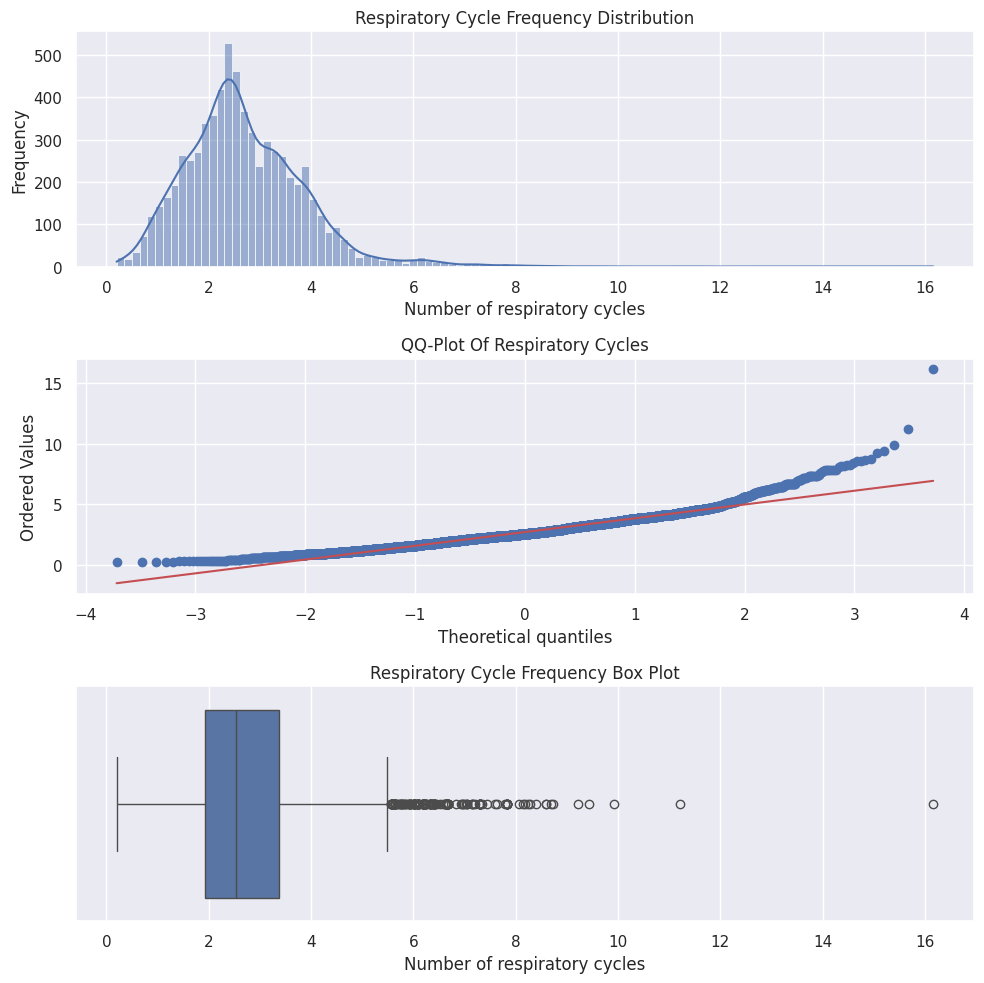

In [106]:
lst_of_respiratory_cycle_duration = [data['len'] for data in dataset]

fig, ax = plt.subplots(3, 1, figsize=(10, 10))

sns.histplot(lst_of_respiratory_cycle_duration, kde=True, ax=ax[0])
ax[0].set_title("Respiratory Cycle Frequency Distribution")
ax[0].set_xlabel("Number of respiratory cycles")
ax[0].set_ylabel("Frequency")

stats.probplot(lst_of_respiratory_cycle_duration, dist="norm", plot=ax[1])
ax[1].set_title("QQ-Plot Of Respiratory Cycles")

sns.boxplot(x=lst_of_respiratory_cycle_duration, ax=ax[2])
ax[2].set_title("Respiratory Cycle Frequency Box Plot")
ax[2].set_xlabel("Number of respiratory cycles")

plt.tight_layout()
plt.show()

#### Respiratory cycles are rightly skewed, which gave us enough information to pad or truncate our input. In future when feeding input to model we can take the `max_len` of an input audio, which might me our ground truth's 95th percentile.

In [107]:
print(f"95th percentile of all respiratory cycles are: {np.percentile(lst_of_respiratory_cycle_duration, 95):.2f} seconds.")

95th percentile of all respiratory cycles are: 4.59 seconds.


In [109]:
# Disease Class Count
class_counts = {}

for data in tqdm(dataset, desc="Getting counts..."):
    cls = data['class']
    if cls not in class_counts:
        class_counts[cls] = 1
    else:
        class_counts[cls] += 1

Getting counts...: 100%|██████████| 6898/6898 [00:00<00:00, 1341570.48it/s]


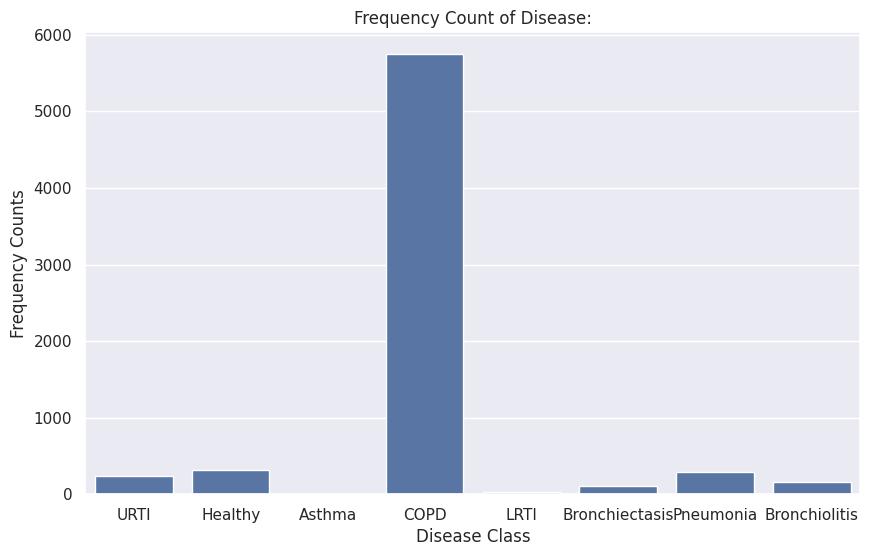

In [110]:
plt.figure(figsize=(10,6))
sns.barplot(
    x=list(class_counts.keys()),
    y=list(class_counts.values())
)

plt.xlabel("Disease Class")
plt.ylabel("Frequency Counts")
plt.title("Frequency Count of Disease:")
plt.show()

Clearly COPD is dominating class, and also we should remove rare classes like asthma (1 count) and LRTI (2 counts).

- We can either drop some of rare class.
- We can oversample minority class.

In both ways we have to drop asthma and LRTI classes because of too low frequency.

In [ ]:
def pad_truncate(waveform):
    if len(waveform) > WINDOW_SIZE:
        return waveform[:WINDOW_SIZE]
        
    padded_waveform = np.pad(
        waveform,
        (0, WINDOW_SIZE-len(waveform)),
        mode='constant', 
        constant_values=0
    )
    
    return padded_waveform

### Change in waveform across each class

In [172]:
cycle_class_array = {}

for data in tqdm(dataset, desc="Averaging Waveform..."):
    waveform, sr = librosa.load(data['wav_path'], sr=SAMPLING_RATE)

    processed_waveform = pad_truncate(waveform)
    
    cycle_label = CLS_TO_CYCLE_LABEL.get(data['cycle_class'])
    if cycle_label not in cycle_class_array:
        cycle_class_array[cycle_label] = [processed_waveform]
    else:
        cycle_class_array[cycle_label].append(processed_waveform)

Averaging Waveform...: 100%|██████████| 6898/6898 [00:14<00:00, 472.15it/s]


In [176]:
avg_normal_waveform = np.mean(cycle_class_array['Normal'], axis=0)
avg_crackles_waveform = np.mean(cycle_class_array['Crackles'], axis=0)
avg_wheezes_waveform = np.mean(cycle_class_array['Wheezes'], axis=0)
avg_both_waveform = np.mean(cycle_class_array['Both'], axis=0)

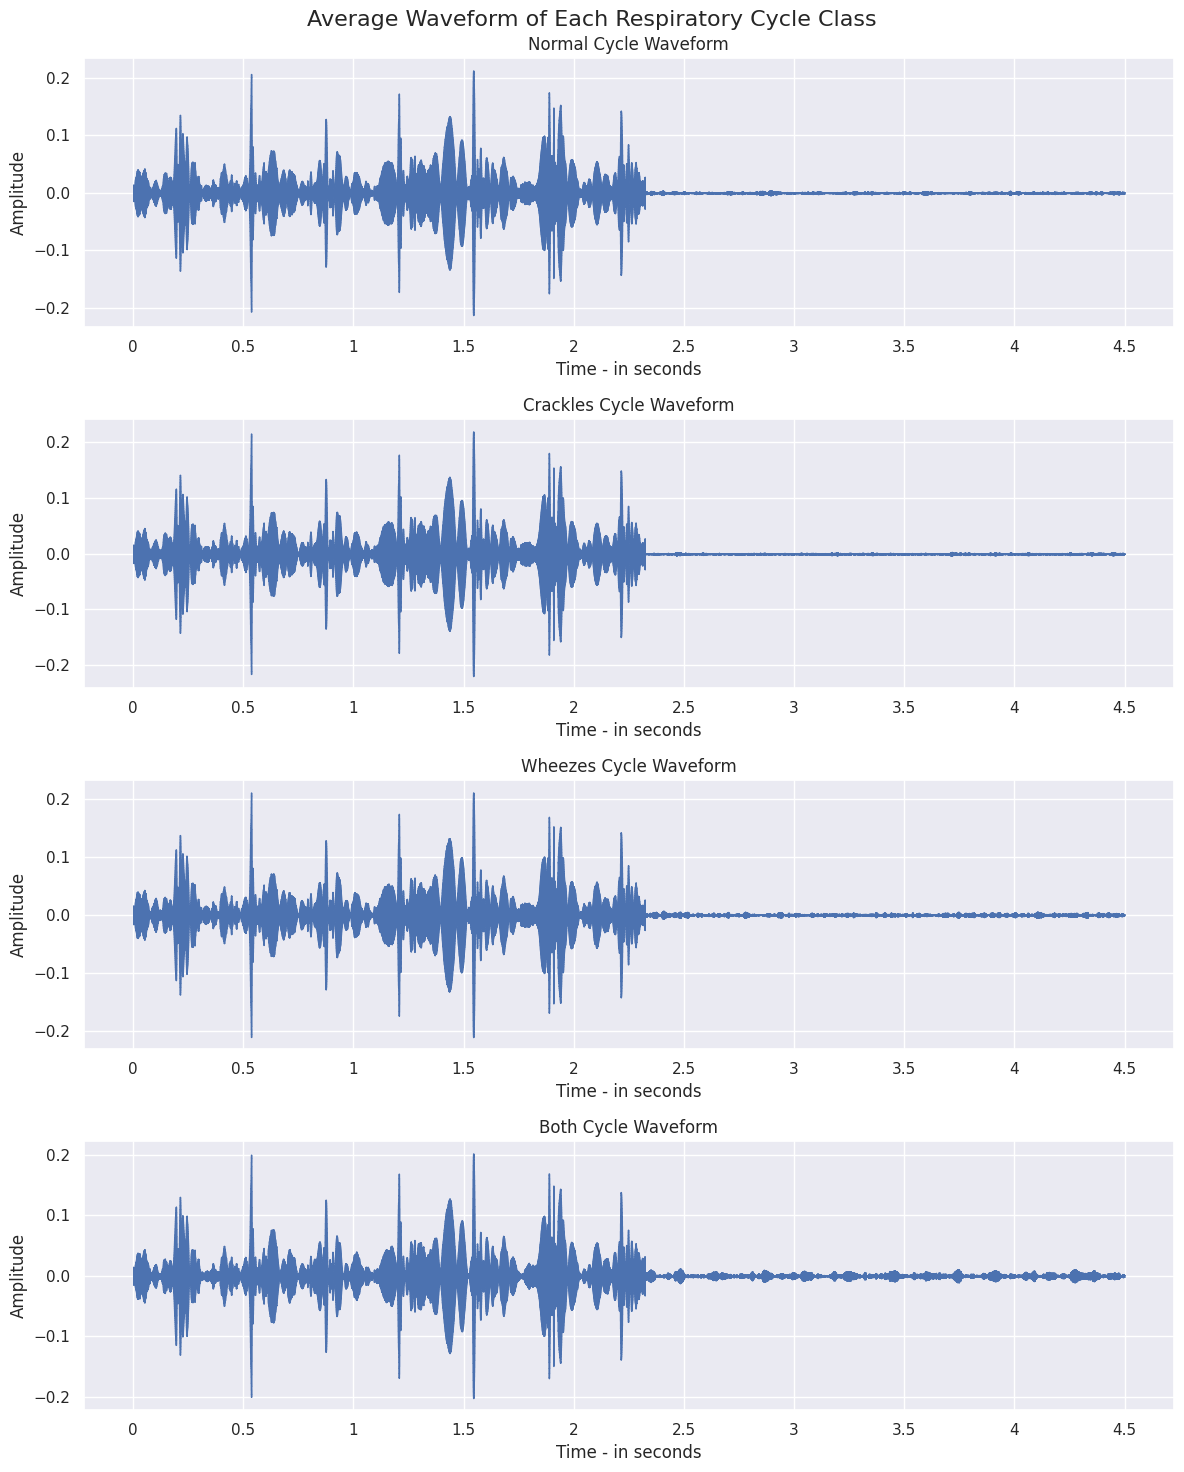

In [195]:
fig, ax = plt.subplots(4, 1, figsize=(12, 15))

librosa.display.waveshow(avg_normal_waveform, sr=SAMPLING_RATE, ax=ax[0])
ax[0].set_title("Normal Cycle Waveform")
ax[0].set_xlabel("Time - in seconds")
ax[0].set_ylabel("Amplitude")

librosa.display.waveshow(avg_crackles_waveform, sr=SAMPLING_RATE, ax=ax[1])
ax[1].set_title("Crackles Cycle Waveform")
ax[1].set_xlabel("Time - in seconds")
ax[1].set_ylabel("Amplitude")

librosa.display.waveshow(avg_wheezes_waveform, sr=SAMPLING_RATE, ax=ax[2])
ax[2].set_title("Wheezes Cycle Waveform")
ax[2].set_xlabel("Time - in seconds")
ax[2].set_ylabel("Amplitude")

librosa.display.waveshow(avg_both_waveform, sr=SAMPLING_RATE, ax=ax[3])
ax[3].set_title("Both Cycle Waveform")
ax[3].set_xlabel("Time - in seconds")
ax[3].set_ylabel("Amplitude")

fig.suptitle("Average Waveform of Each Respiratory Cycle Class", fontsize=16)

plt.tight_layout()
plt.show()

All average waveform looks `similary`, and we can notice in "**Both**" respiratory class when *crackles* and *wheeze* both present in a respiratory cycle, consequently the length of each respiratory cycle also `increase`, that's the reasing why after `2.5 (approx)` seconds"Both" average waveform **starts amplifying**. It means this the location **long respiratory cycles are present**. 

In [263]:
disease_class_array = {}

for data in tqdm(dataset, desc="Averaging Spectrograms..."):
    waveform, sr = librosa.load(data['wav_path'], sr=SAMPLING_RATE)

    padded_waveform = pad_truncate(waveform)
    spec = librosa.feature.melspectrogram(y=padded_waveform, sr=sr, n_mels=128)
    
    spec_db = librosa.power_to_db(spec, ref=np.max)
    
    disease_label = data['class']
    if disease_label not in disease_class_array:
        disease_class_array[disease_label] = [spec_db]
    else:
        disease_class_array[disease_label].append(spec_db)

Averaging Spectrograms...: 100%|██████████| 6898/6898 [01:28<00:00, 78.08it/s]


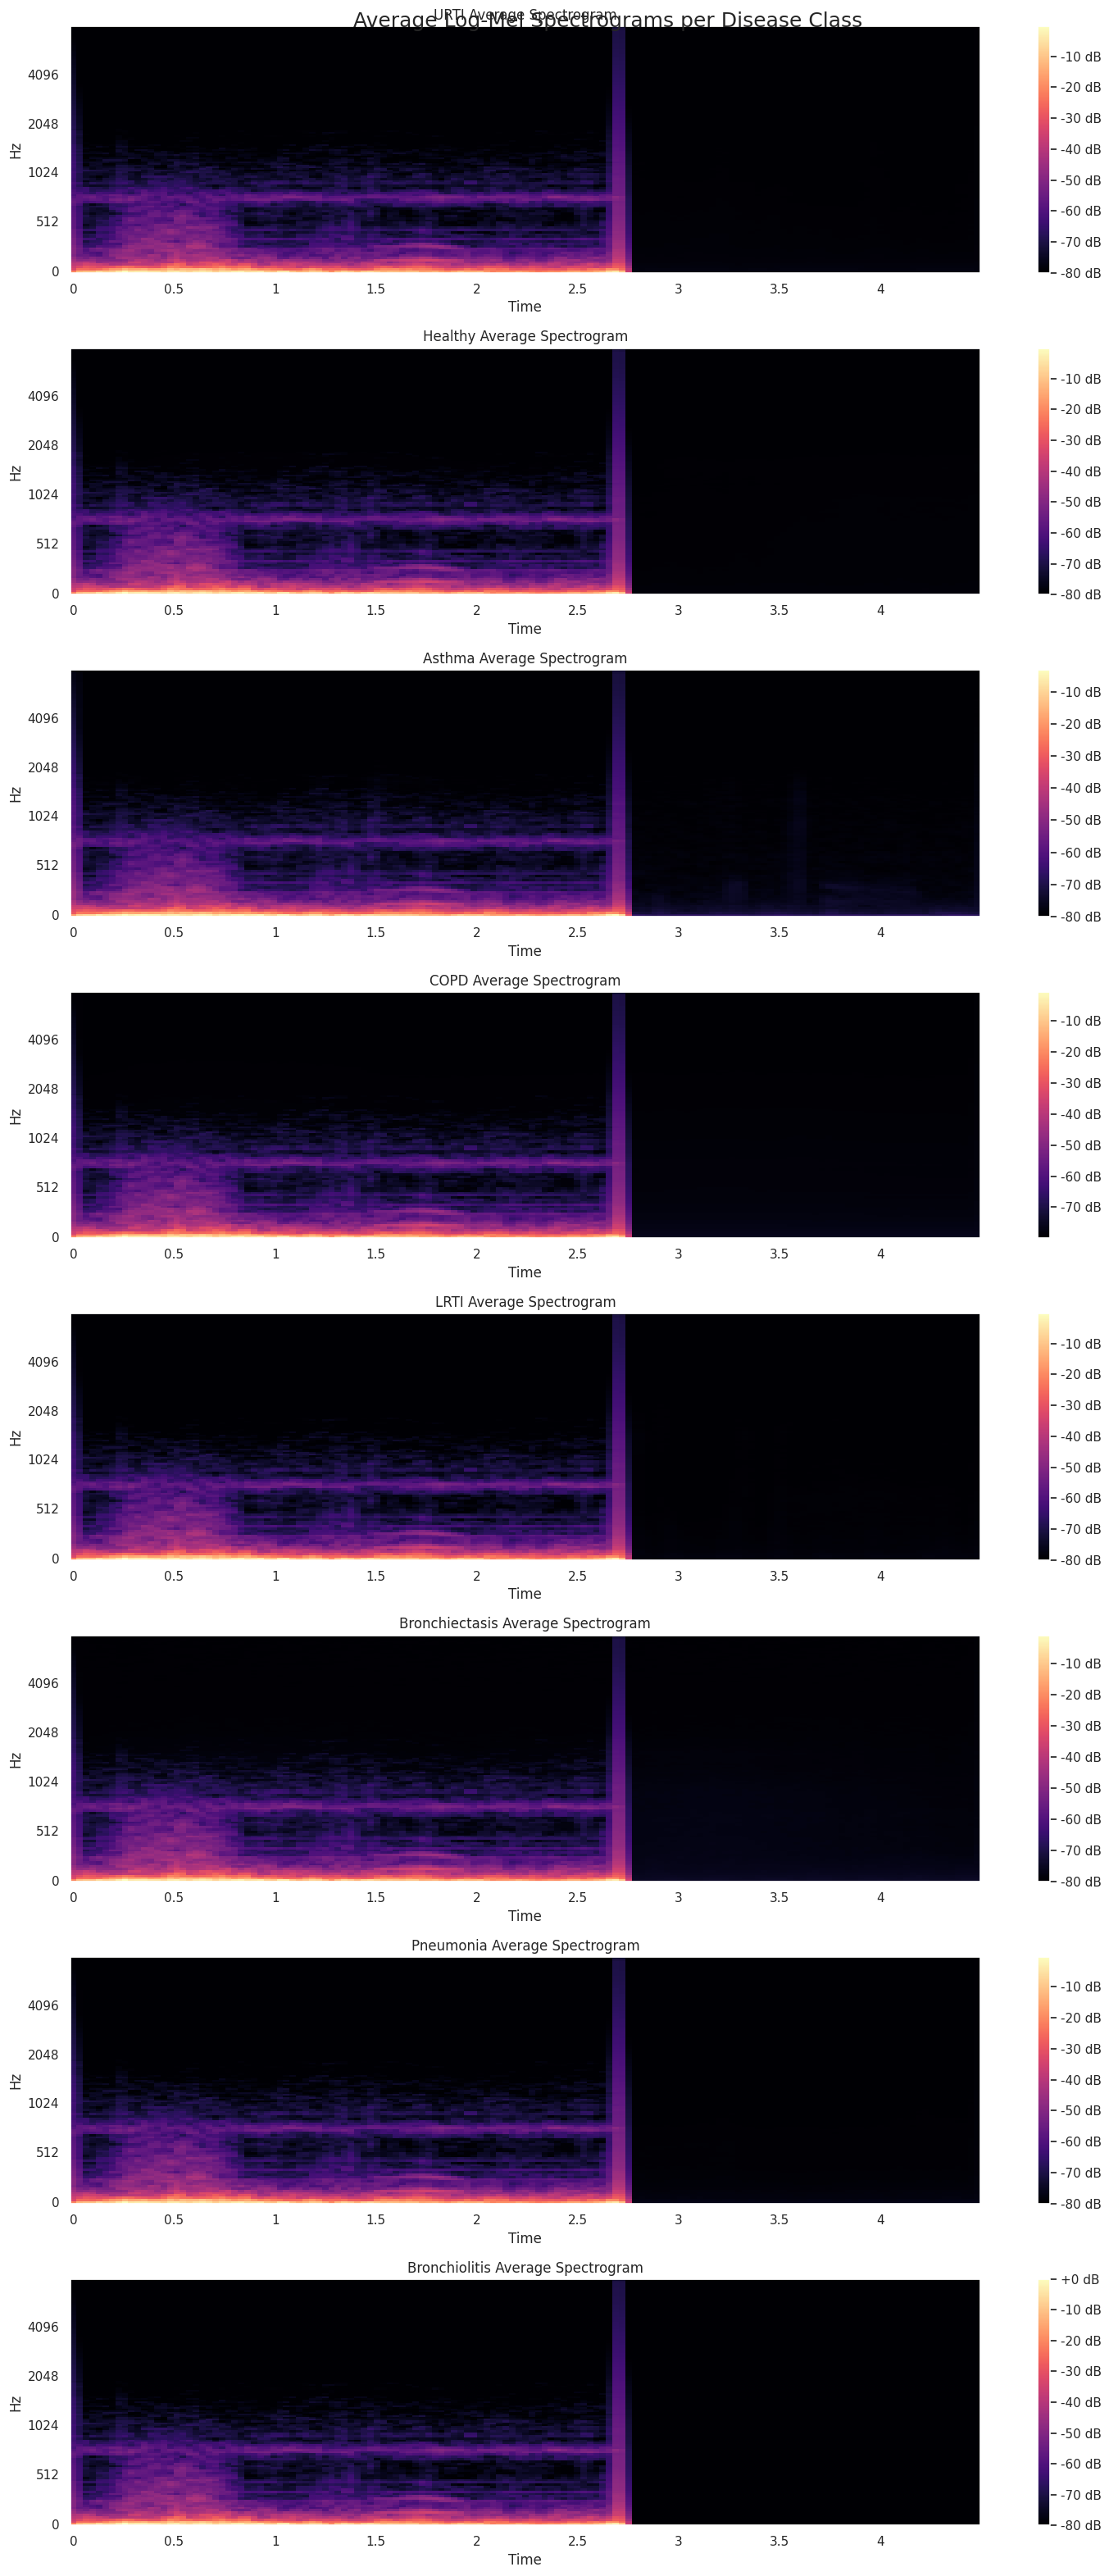

In [270]:
fig, ax = plt.subplots(len(disease_class_array), 1, figsize=(15, 4 * len(disease_class_array)))

for i, (key, values) in enumerate(disease_class_array.items()):

    avg_spectrogram = np.mean(values, axis=0)

    img = librosa.display.specshow(
        avg_spectrogram,
        x_axis='time',
        y_axis='mel',
        sr=SAMPLING_RATE,
        ax=ax[i]
    )

    ax[i].set_title(f"{key} Average Spectrogram")

    fig.colorbar(img, ax=ax[i], format='%+2.0f dB')

fig.suptitle("Average Log-Mel Spectrograms per Disease Class", fontsize=18)

plt.tight_layout()
plt.show()

Again all disease class's repiratory cycles are similar. In order to know each of class differ inherently, we can conduct hypothesis, but hypothesis is not apt for this problem. Our main goal should be "How we help our model to classify between diseases", so we need to apply feature engineering. 

To be continued, at [feature_engineering.ipynb](https://github.com/Ankit6174/Acoustic-Modeling-for-Pulmonary-Disease-Classification/blob/main/Feature%20Engineering.ipynb)